In [1]:
import pandas as pd

# Load the datasets

customers_df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\customer_data.csv")
transactions_df= pd.read_csv("C:\\Users\\Administrator\\Downloads\\transaction_data.csv")

In [2]:
# Printing the DataFrames

customers_df

,customer_id,customer_name,city,signup_date,customer_segment
0,CUST101,Aarav Sharma,Chicago,2023-05-07,VIP
1,CUST102,Priya Kapoor,Mumbai,2024-07-24,Premium
2,CUST103,John Smith,Bangalore,2022-03-19,Premium
3,CUST104,Emma Johnson,Toronto,2022-01-11,VIP
4,CUST105,Liam Brown,Toronto,2022-04-29,Regular
5,CUST106,Olivia Davis,New York,2023-01-30,VIP
6,CUST107,Noah Miller,Mumbai,2021-05-22,Regular
7,CUST108,Ava Wilson,Houston,2022-04-22,VIP
8,CUST109,Ethan Moore,New York,2023-06-14,VIP
9,CUST110,Sophia Taylor,Mumbai,2024-06-15,Premium


In [3]:
transactions_df

,transaction_id,customer_id,transaction_date,product_category,amount
0,TXN1001,CUST118,2024-05-02,Toys,108.53
1,TXN1002,CUST105,2024-07-02,Toys,153.07
2,TXN1003,CUST115,2024-05-28,Toys,165.80
3,TXN1004,CUST116,2024-01-31,Beauty,23.15
4,TXN1005,CUST103,2023-06-12,Groceries,11.39
5,TXN1006,CUST103,2024-07-17,Books,290.04
6,TXN1007,CUST111,2024-07-23,Apparel,98.53
7,TXN1008,CUST106,2024-10-03,Sports,418.49
8,TXN1009,CUST111,2023-12-21,Beauty,130.43
9,TXN1010,CUST106,2023-03-09,Home & Kitchen,390.74


In [4]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       20 non-null     object
 1   customer_name     20 non-null     object
 2   city              20 non-null     object
 3   signup_date       20 non-null     object
 4   customer_segment  20 non-null     object
dtypes: object(5)
memory usage: 932.0+ bytes


In [16]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    20 non-null     object 
 1   customer_id       20 non-null     object 
 2   transaction_date  20 non-null     object 
 3   product_category  20 non-null     object 
 4   amount            20 non-null     float64
dtypes: float64(1), object(4)
memory usage: 932.0+ bytes


In [5]:
print(transactions_df['transaction_date'].head(10))

0    2024-05-02
1    2024-07-02
2    2024-05-28
3    2024-01-31
4    2023-06-12
5    2024-07-17
6    2024-07-23
7    2024-10-03
8    2023-12-21
9    2023-03-09
Name: transaction_date, dtype: object


In [6]:
# Convert '	transaction_date' to datetime format in transaction_df

transactions_df['transaction_date'] = pd.to_datetime(transactions_df['transaction_date'], format = '%Y-%m-%d')

In [15]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    20 non-null     object        
 1   customer_id       20 non-null     object        
 2   transaction_date  20 non-null     datetime64[ns]
 3   product_category  20 non-null     object        
 4   amount            20 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 932.0+ bytes


In [7]:
# Total number of customers in the customer base

customers_df['customer_id'].value_counts().sum()

np.int64(20)

In [8]:
# the total number of customers who place the order

transactions_df['customer_id'].nunique()

13

In [9]:
# Merge the dataset on 'Customer ID'

merged_df=pd.merge(transactions_df, customers_df, on='customer_id', how='inner')

In [10]:
# View the first few rows of the merged data

print("First few rows of the merged DataFrame:")
merged_df.head()

First few rows of the merged DataFrame:


,transaction_id,customer_id,transaction_date,product_category,amount,customer_name,city,signup_date,customer_segment
0,TXN1001,CUST118,2024-05-02,Toys,108.53,Harper Garcia,New York,2023-08-21,Regular
1,TXN1002,CUST105,2024-07-02,Toys,153.07,Liam Brown,Toronto,2022-04-29,Regular
2,TXN1003,CUST115,2024-05-28,Toys,165.80,James Harris,Bangalore,2021-11-26,VIP
3,TXN1004,CUST116,2024-01-31,Beauty,23.15,Amelia Martin,Delhi,2023-04-02,Premium
4,TXN1005,CUST103,2023-06-12,Groceries,11.39,John Smith,Bangalore,2022-03-19,Premium


In [26]:
#  Get concise summary of merged dataframes

print("\nSummary of the merged DataFrame:")
print(merged_df.info())


Summary of the merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    20 non-null     object        
 1   customer_id       20 non-null     object        
 2   transaction_date  20 non-null     datetime64[ns]
 3   product_category  20 non-null     object        
 4   amount            20 non-null     float64       
 5   customer_name     20 non-null     object        
 6   city              20 non-null     object        
 7   signup_date       20 non-null     object        
 8   customer_segment  20 non-null     object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 1.5+ KB
None


In [27]:
# Check for missing values in the merged DataFrame

print("\nMissing values in each column:")
print(merged_df.isnull().sum())


Missing values in each column:
transaction_id      0
customer_id         0
transaction_date    0
product_category    0
amount              0
customer_name       0
city                0
signup_date         0
customer_segment    0
dtype: int64


In [28]:
# Group by product category and get total sales and amount

product_summary = merged_df.groupby('product_category')['amount'].sum()

product_summary

product_category
Apparel            323.75
Beauty             259.01
Books              758.82
Electronics        761.32
Groceries           11.39
Home & Kitchen    1363.73
Sports             669.04
Toys               471.43
Name: amount, dtype: float64

In [15]:
# Groupby city and amount and customer_segment

get_summary = merged_df.groupby('city').agg({'amount':'sum', 'customer_segment':'sum'})

get_summary

,amount,customer_segment
city,,
Bangalore,808.42,VIPPremiumPremiumVIP
Delhi,570.33,PremiumRegularPremium
Houston,750.35,VIPVIPVIP
Los Angeles,670.68,RegularRegular
Mumbai,27.03,Premium
New York,1638.61,RegularVIPVIPVIPVIPVIP
Toronto,153.07,Regular


In [18]:
# Groupby city and amount and product_category

city_summary = merged_df.groupby('city').agg({'amount':'sum','product_category':'count'})

city_summary

,amount,product_category
city,,
Bangalore,808.42,4
Delhi,570.33,3
Houston,750.35,3
Los Angeles,670.68,2
Mumbai,27.03,1
New York,1638.61,6
Toronto,153.07,1


In [12]:
# Filtering transactions with total price above 100.00

high_value_transactions = merged_df[merged_df['amount']>350.00]
high_value_transactions

,transaction_id,customer_id,transaction_date,product_category,amount,customer_name,city,signup_date,customer_segment
7,TXN1008,CUST106,2024-10-03,Sports,418.49,Olivia Davis,New York,2023-01-30,VIP
9,TXN1010,CUST106,2023-03-09,Home & Kitchen,390.74,Olivia Davis,New York,2023-01-30,VIP
11,TXN1012,CUST108,2024-02-21,Home & Kitchen,481.10,Ava Wilson,Houston,2022-04-22,VIP
13,TXN1014,CUST113,2024-11-13,Books,468.78,Lucas Jackson,Delhi,2021-02-17,Regular
15,TXN1016,CUST114,2024-05-09,Electronics,420.13,Mia White,Los Angeles,2021-09-13,Regular
18,TXN1019,CUST111,2024-10-22,Home & Kitchen,491.89,Mason Anderson,New York,2022-11-05,VIP


<Axes: title={'center': 'total amount by product_category'}, xlabel='city'>

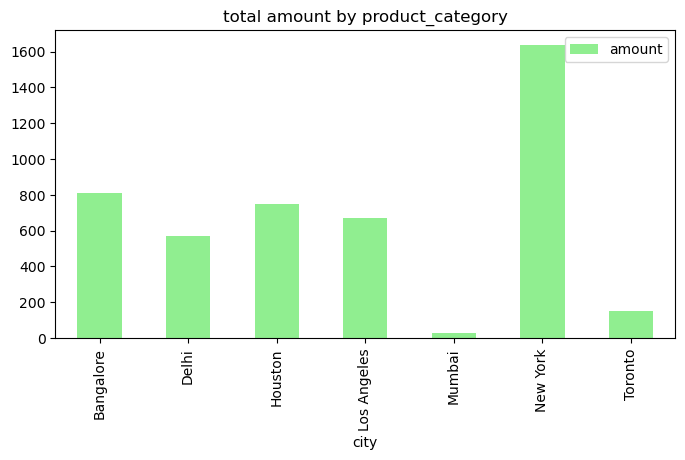

In [21]:
# Plotting

# Total amounts by product_category

get_summary.plot(
    kind='bar', 
    figsize=(8,4), 
    title='total amount by product_category',
    color='lightgreen'
)


<Axes: title={'center': 'total amount by city'}, xlabel='city'>

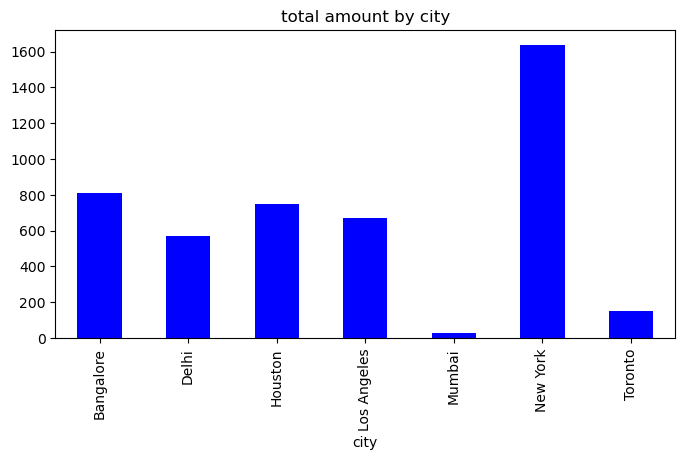

In [19]:
# total sales by city

city_summary['amount'].plot(kind='bar',
                    figsize=(8,4),
                    title='total amount by city',
                    color='blue'
                   )